In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [57]:
ad_raw = sc.read_h5ad('../data/mtDNA_DSB_5k_raw.h5ad')

In [60]:
ad_raw

AnnData object with n_obs × n_vars = 983582 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run'

In [61]:
ad

AnnData object with n_obs × n_vars = 980474 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap', 'de_mtDSB'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [2]:
ad = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation.h5ad')

In [4]:
import pandas as pd

# contingency table
ct_counts = pd.crosstab(ad.obs["cell_class"], [ad.obs["condition"], ad.obs["age"]])

# normalize within condition/age
ct_frac = ct_counts.div(ct_counts.sum(axis=0), axis=1)

# difference mtDSB - control at each age
diff = ct_frac.xs("mtDSB", level="condition", axis=1) - ct_frac.xs("control", level="condition", axis=1)

print(diff.sort_values(by="21"))  # or "60"

age                                       21        60
cell_class                                            
Unknown                            -0.028806  0.000265
Striatal neurons                   -0.022544  0.013248
Mature oligodendrocytes            -0.011292 -0.010431
D1 medium spiny neurons (striatum) -0.002542  0.006709
Chorid plexus epithelial cells     -0.002503  0.001347
Endothelial cells                  -0.001520  0.000324
Neurons                            -0.001259  0.018512
Mature oligodendrocytes (mic)      -0.000638 -0.000782
Oligodendrocytes precursor cells    0.000233 -0.001438
Ependymal cells                     0.000431 -0.000019
Olfactory astrocytes                0.001023 -0.000603
Pericytes                           0.001168 -0.008058
Microglia                           0.001355  0.003671
Cholinergic neurons                 0.001598 -0.001615
Excitatory neurons (thalamus)       0.002332 -0.003332
Neural progenitors                  0.002676 -0.002242
Vascular e

In [6]:
import scanpy as sc
import numpy as np

effect_size = {}

for ct in ad.obs["cell_type"].unique():
    sub = ad[ad.obs["cell_type"] == ct]
    if sub.n_obs < 50:  # skip small groups
        continue
    
    sc.tl.pca(sub, svd_solver="arpack")
    # condition separation on PC1
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
    lda = LDA(n_components=1)
    X = sub.obsm["X_pca"][:, :10]
    y = sub.obs["condition"].values
    score = lda.fit(X, y).score(X, y)
    effect_size[ct] = 1 - score  # higher = more affected

In [7]:
effect_size

{'Mature oligodendrocytes IV': 0.4078123080702616,
 'Excitatory neurons I': 0.45673950277676856,
 'Excitatory neurons III': 0.4175654853620955,
 'Excitatory neurons VI': 0.4342914233015678,
 'Mature oligodendrocytes III': 0.4209744403552014,
 'Telencephalon astrocytes II': 0.39883928058380735,
 'Mature oligodendrocytes I': 0.414245100805139,
 'Microglia I': 0.40513508978016444,
 'Excitatory neurons II': 0.40764381820108064,
 'Excitatory neurons IV': 0.42631156151517025,
 'Vascular leptomeningeal cells I': 0.43909472760328505,
 'Inhibitory neurons I': 0.4717891610987379,
 'Telencephalon astrocytes I': 0.4245643548062682,
 'Mature oligodendrocytes (mic) I': 0.4206377642422071,
 'Mature oligodendrocytes II': 0.3781117895725693,
 'Excitatory neurons (cortex) II': 0.42141256471679156,
 'Oligodendrocytes precursor cells I': 0.46717087765957444,
 'Pericytes I': 0.4245804870804871,
 'Vascular endothelial cells I': 0.45175691244239635,
 'Endothelial cells I': 0.43957258658806186,
 'Neural proge

Mature oligodendrocytes


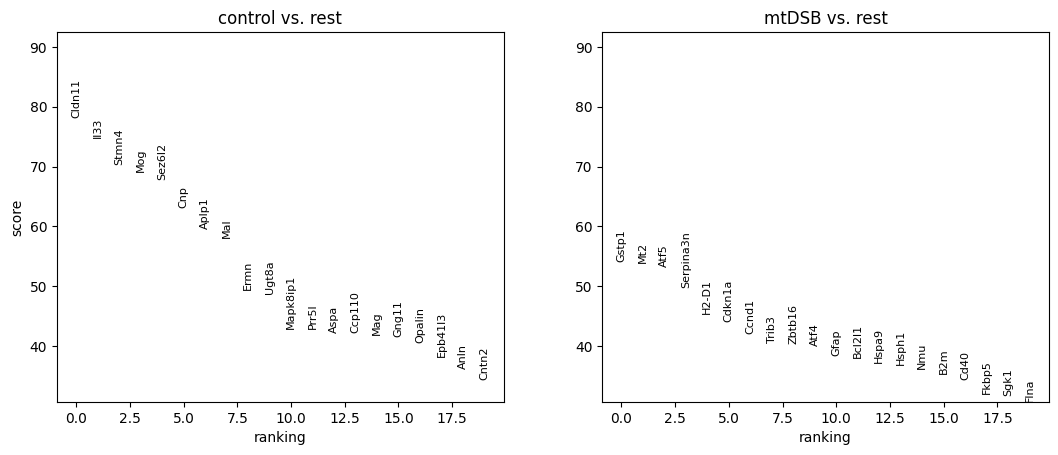

Excitatory neurons


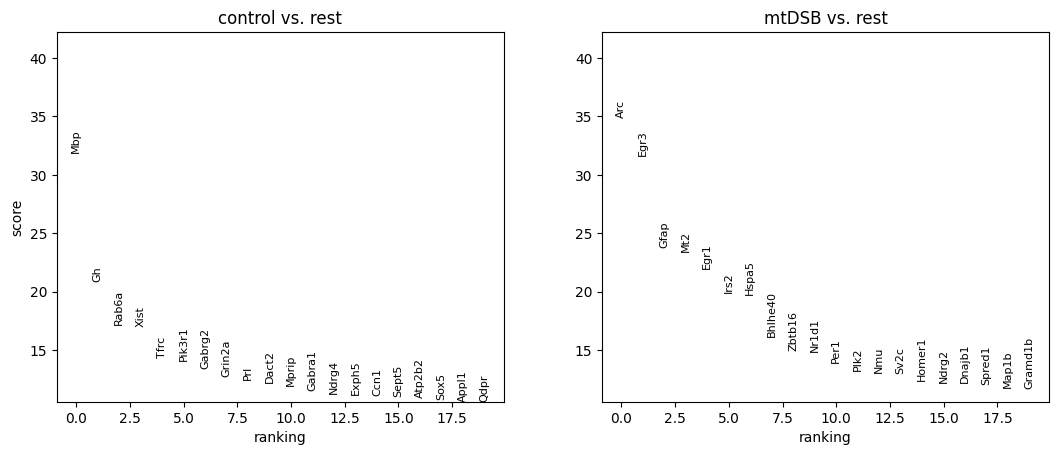

Telencephalon astrocytes


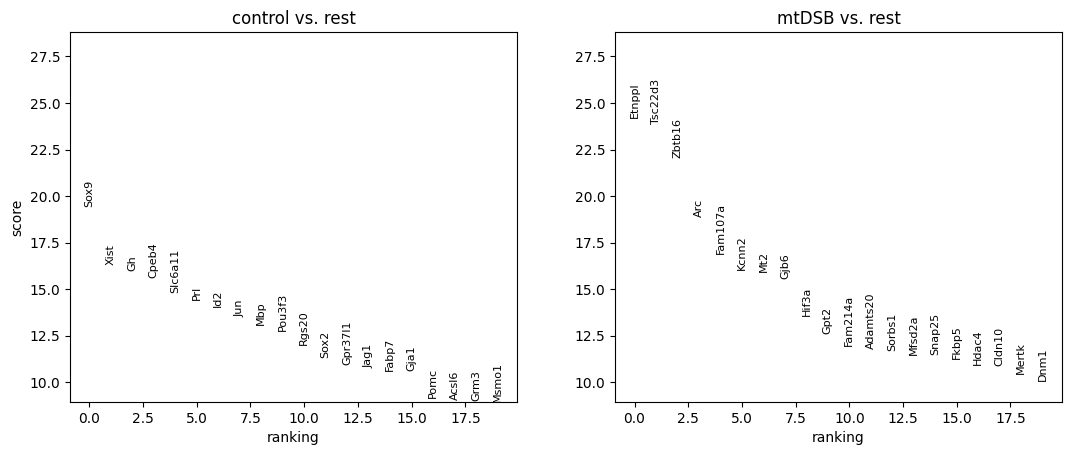

Microglia


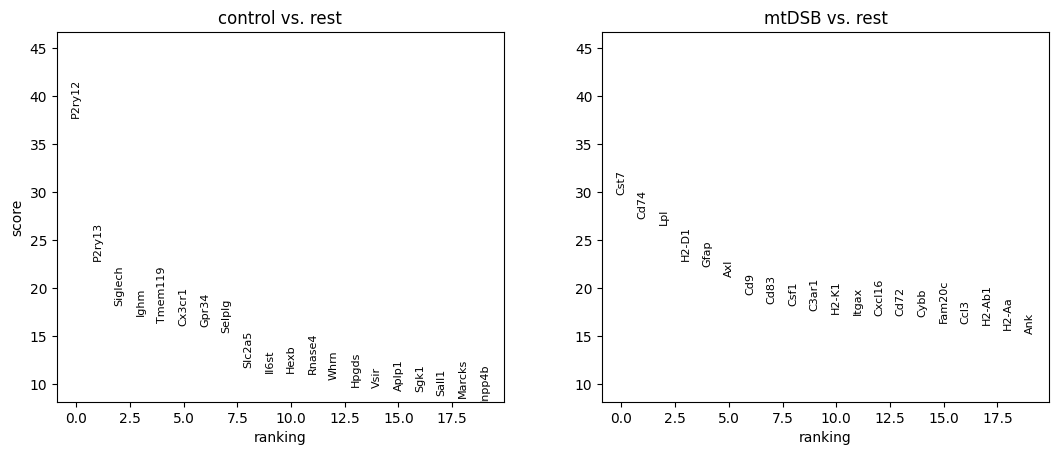

Vascular leptomeningeal cells


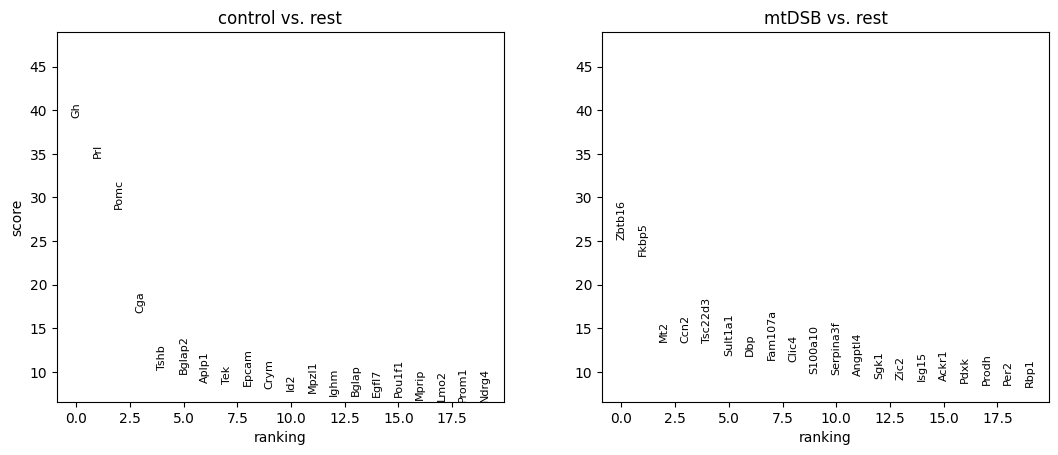

Inhibitory neurons


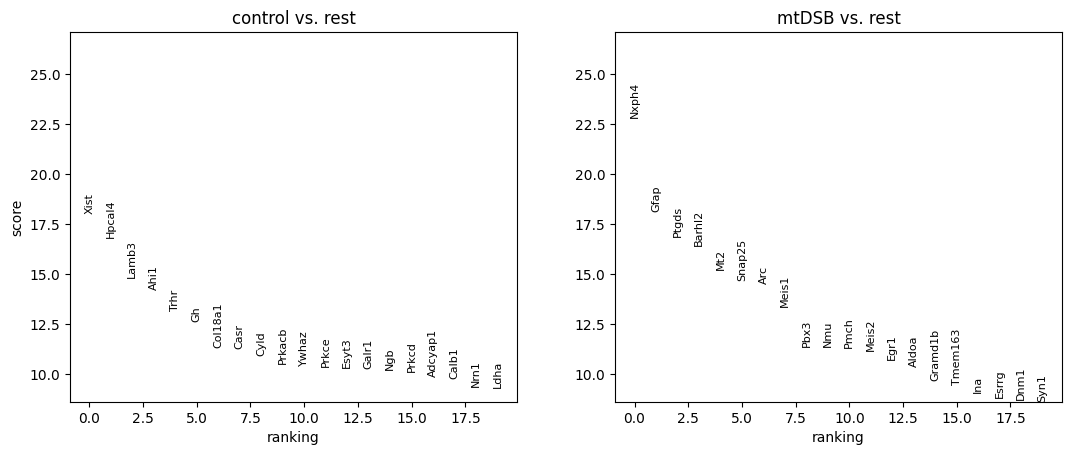

Mature oligodendrocytes (mic)


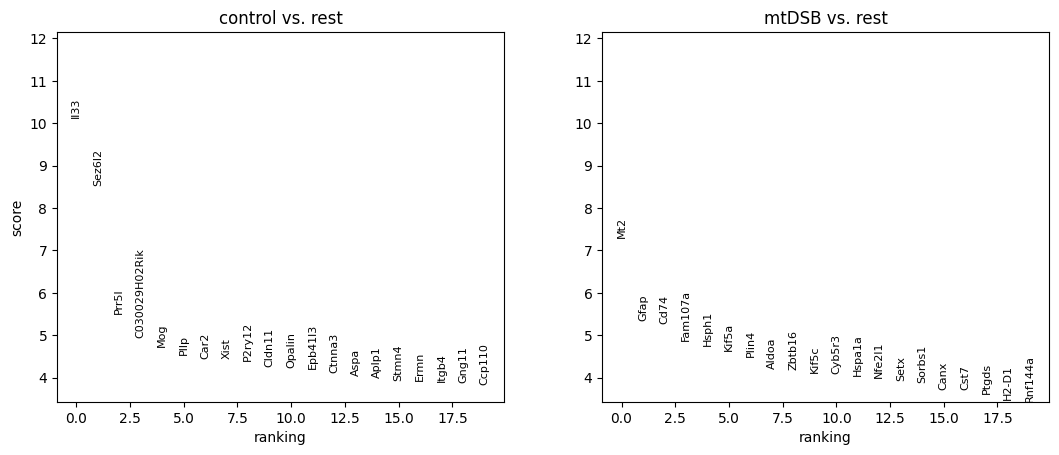

Excitatory neurons (cortex)


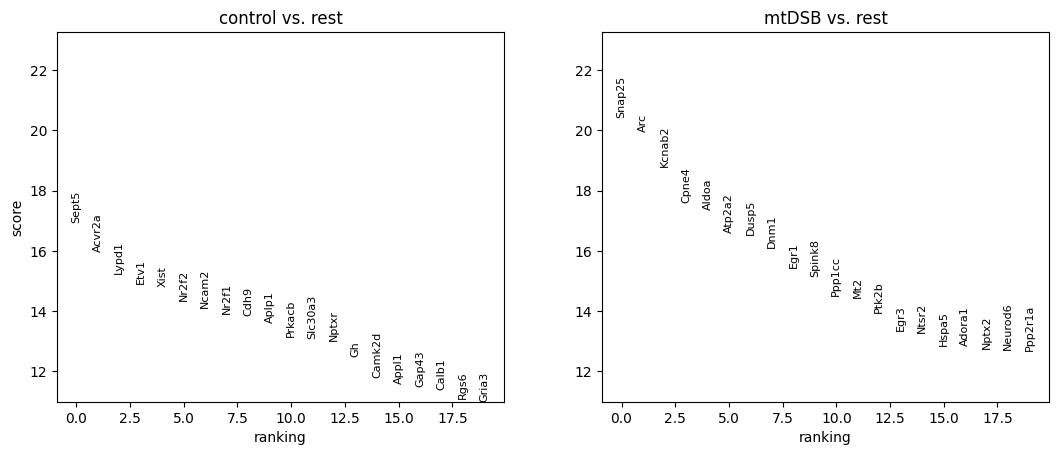

Oligodendrocytes precursor cells


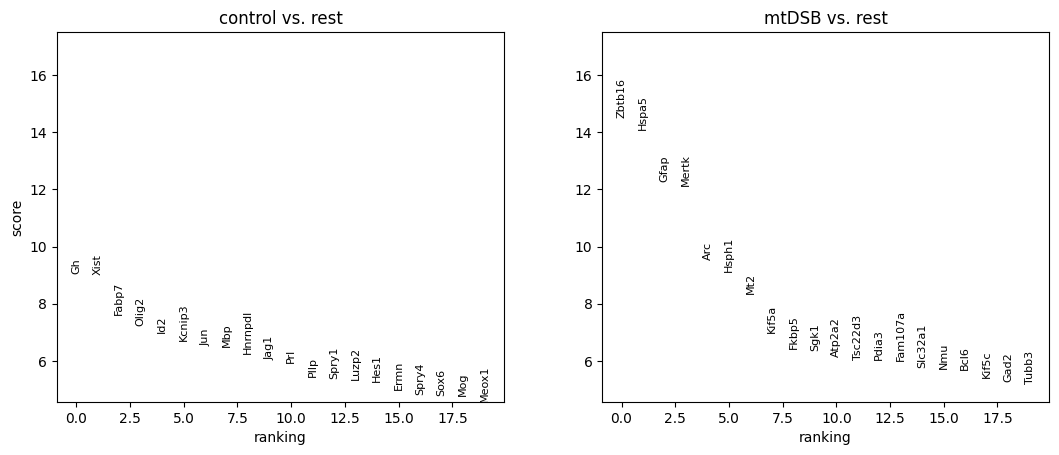

Pericytes


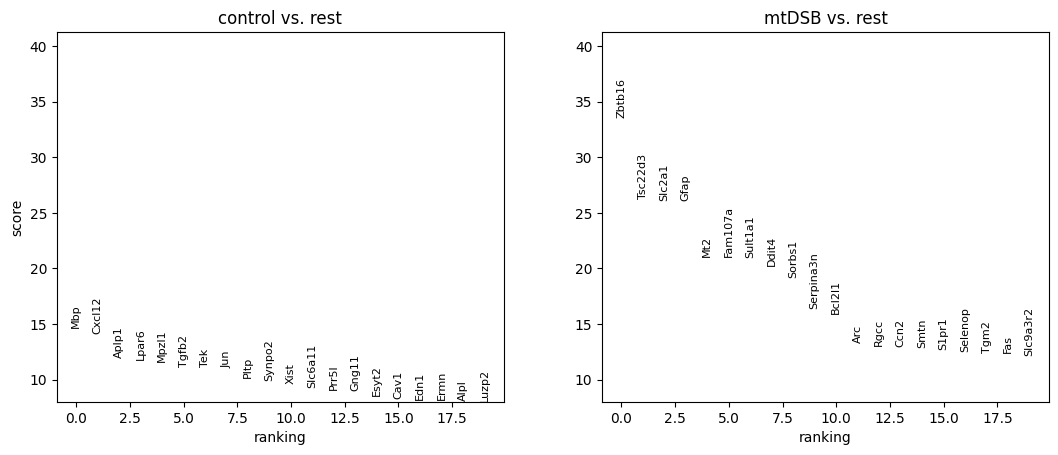

Vascular endothelial cells


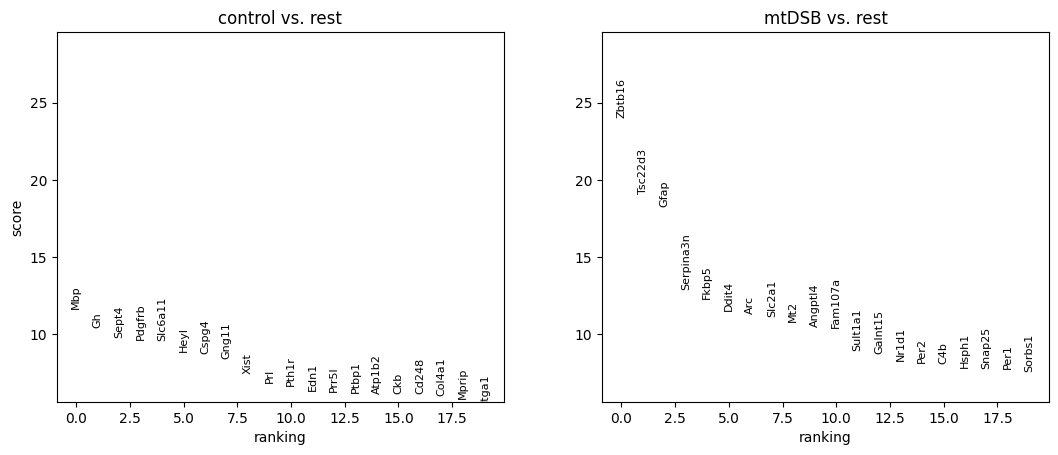

Endothelial cells


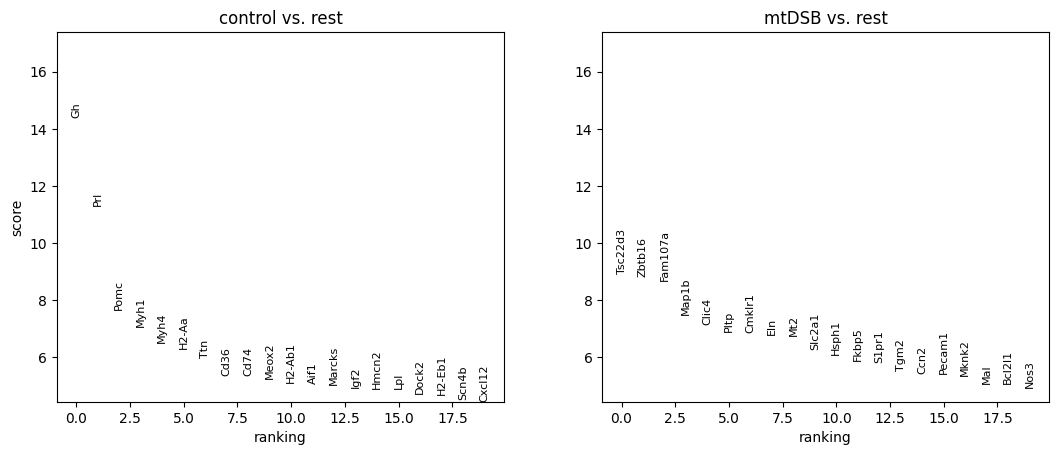

Neural progenitors


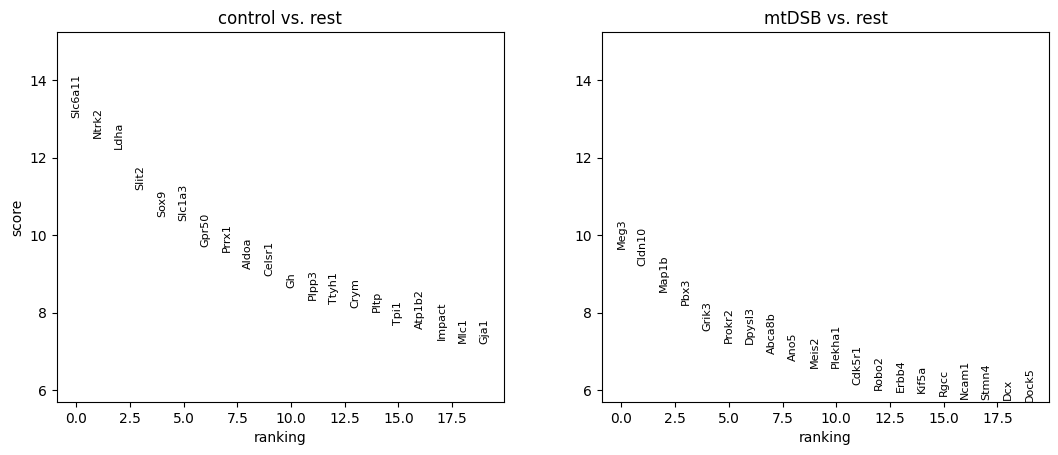

Ependymal cells


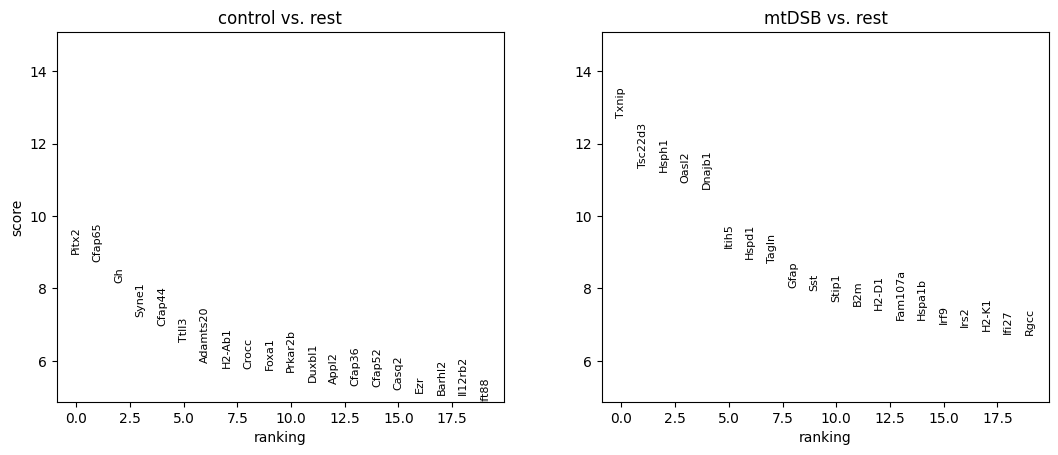

Cholinergic neurons


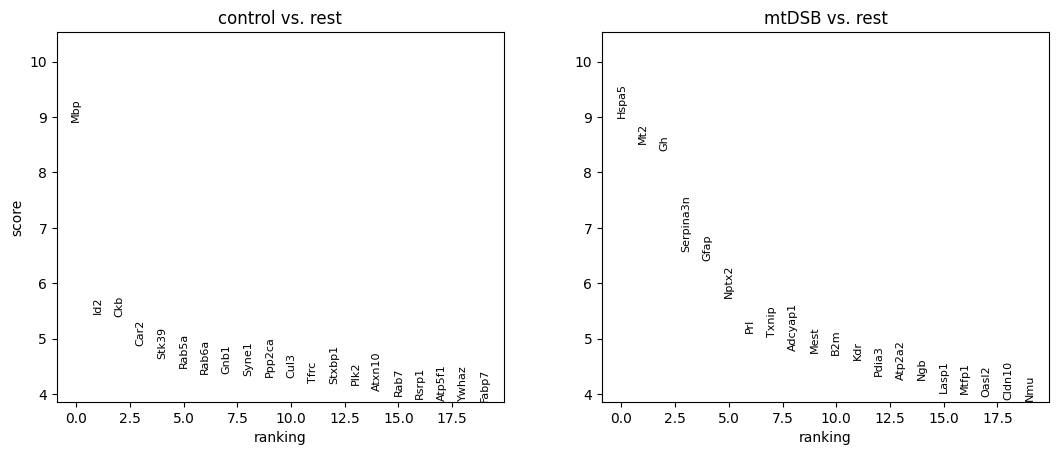

Chorid plexus epithelial cells


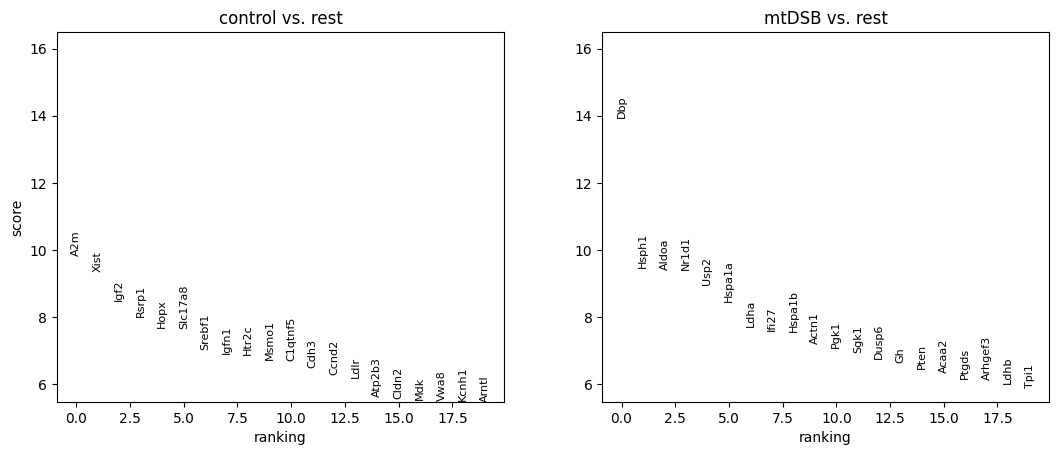

Unknown


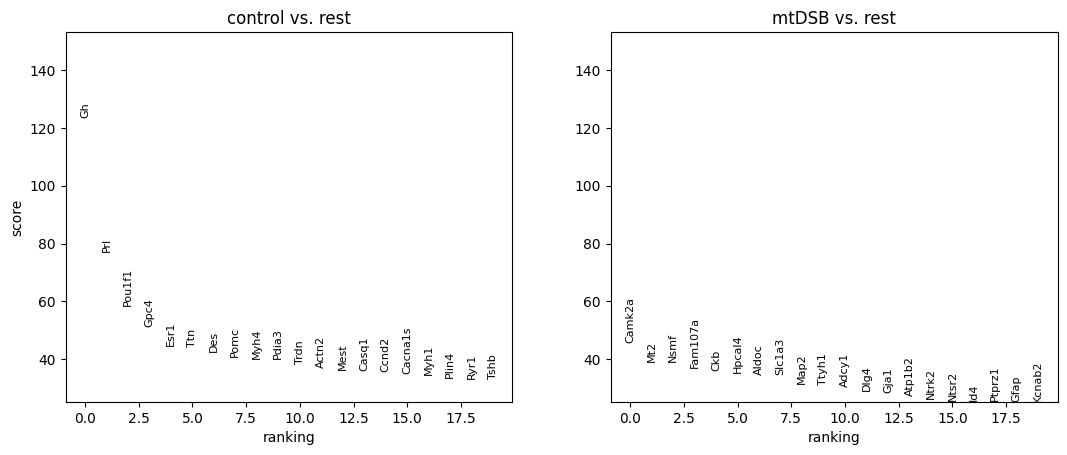

Neurons


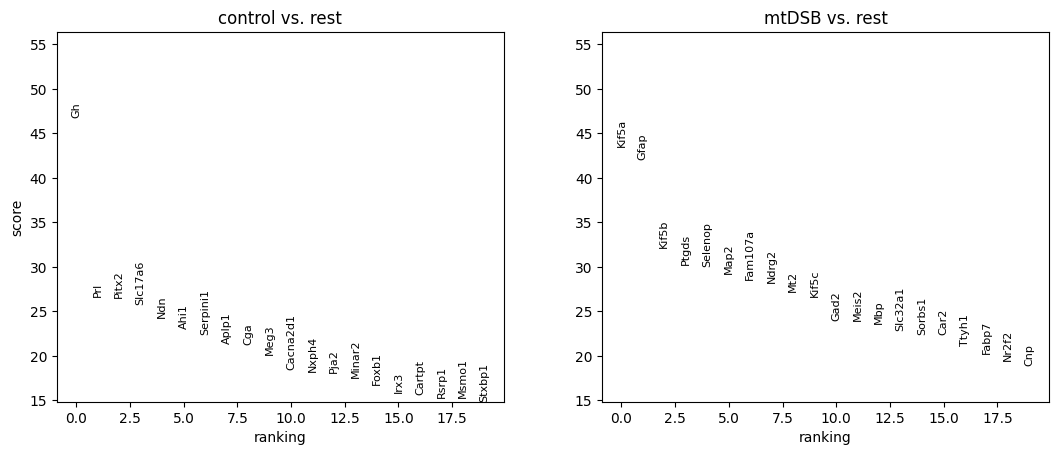

Olfactory astrocytes


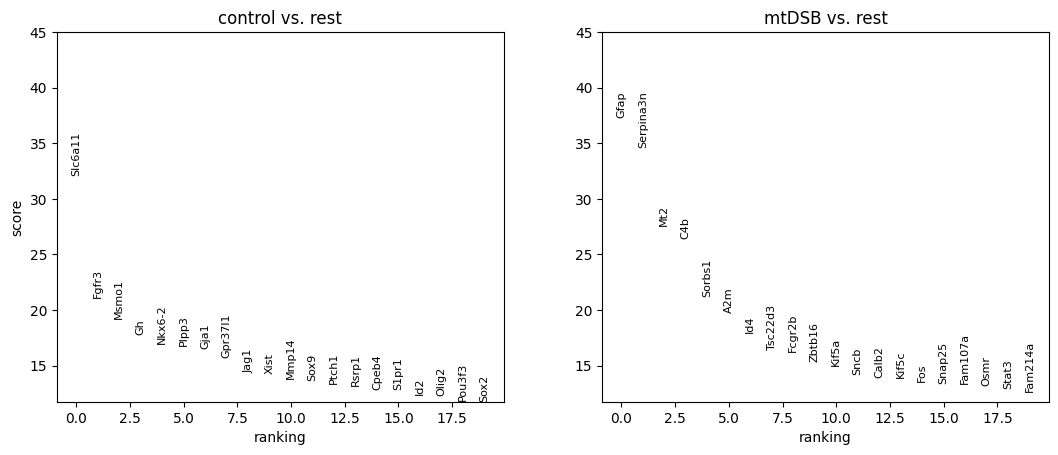

Striatal neurons


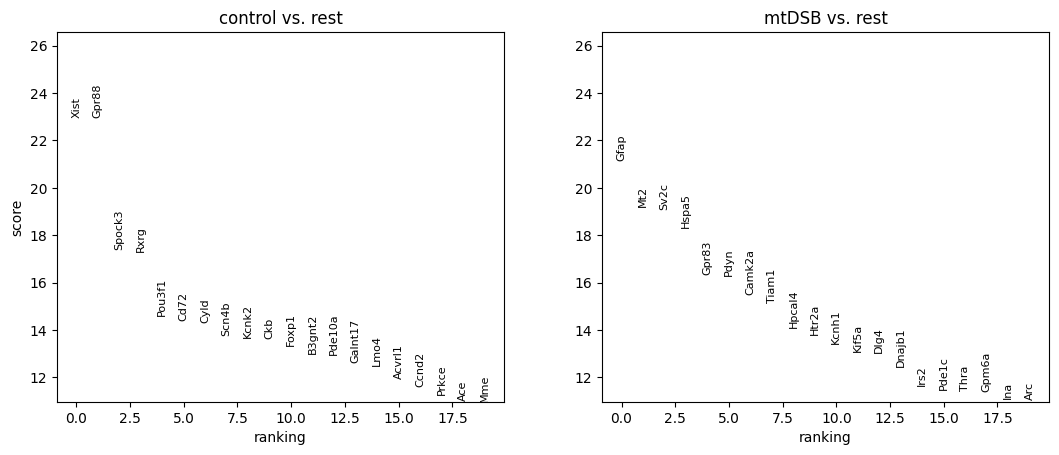

Excitatory neurons (thalamus)


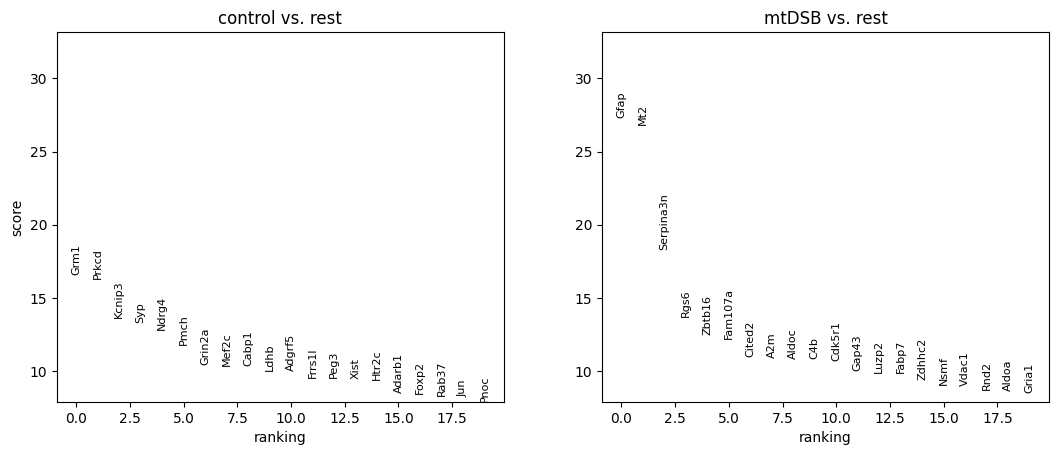

D1 medium spiny neurons (striatum)


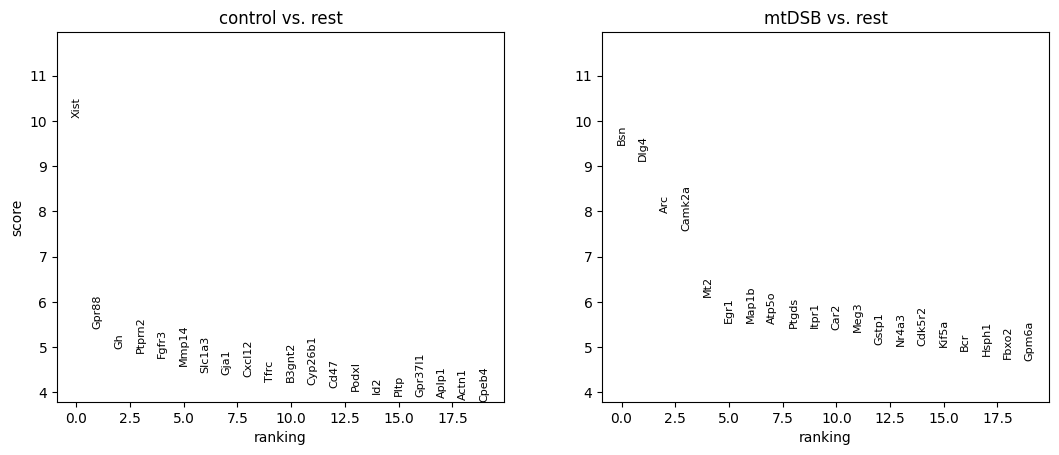

[('Unknown', 2583),
 ('Mature oligodendrocytes', 2297),
 ('Neurons', 1903),
 ('Excitatory neurons', 1270),
 ('Excitatory neurons (cortex)', 1250),
 ('Olfactory astrocytes', 1094),
 ('Inhibitory neurons', 924),
 ('Striatal neurons', 873),
 ('Excitatory neurons (thalamus)', 751),
 ('Telencephalon astrocytes', 728),
 ('Microglia', 614),
 ('Vascular leptomeningeal cells', 560),
 ('Vascular endothelial cells', 470),
 ('Pericytes', 448),
 ('Neural progenitors', 446),
 ('Ependymal cells', 260),
 ('Chorid plexus epithelial cells', 216),
 ('Oligodendrocytes precursor cells', 149),
 ('D1 medium spiny neurons (striatum)', 116),
 ('Endothelial cells', 112),
 ('Cholinergic neurons', 73),
 ('Mature oligodendrocytes (mic)', 42)]

In [12]:
from collections import Counter
import scanpy as sc

de_counts = {}

for ct in ad.obs["cell_class"].unique():
    print(ct)
    sub = ad[ad.obs["cell_class"] == ct]
    if sub.n_obs < 50:
        continue
    sc.tl.rank_genes_groups(sub, groupby="condition", method="t-test")
    sc.pl.rank_genes_groups(sub)
    res = sc.get.rank_genes_groups_df(sub, group="mtDSB")
    de_counts[ct] = (res["pvals_adj"] < 0.05).sum()

# cell types with most DE genes
sorted(de_counts.items(), key=lambda x: x[1], reverse=True)

In [13]:
sub = ad[ad.obs["cell_class"].isin(['Mature oligodendrocytes','Oligodendrocytes precursor cells'])]

In [18]:
sub.obs['condition-age'] = sub.obs['condition'].astype(str) + '-'+ sub.obs['age'].astype(str)

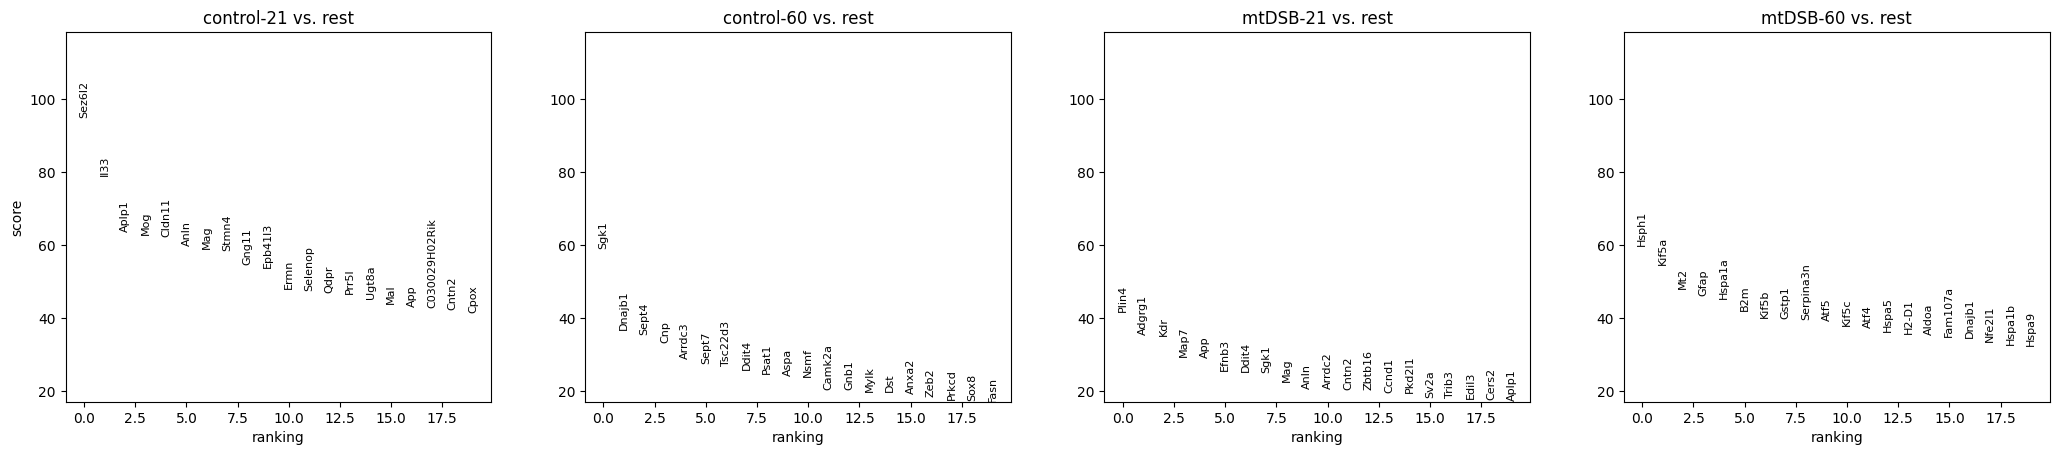

In [19]:
sc.tl.rank_genes_groups(sub, groupby="condition-age", method="t-test")
sc.pl.rank_genes_groups(sub)

In [33]:
mtDSB_genes = [
    "Hspa5", "Hspa9", "Hsph1",
    "Atf5", "Trib3", "Zbtb16", "Ddit3",
    "Cdkn1a", "Bcl2l1",
    "Sgk1", "Nmu", "Plin4", "Aldoa",
    "Serpina3n", "Mt2", "Gstp1",'Ldha'
]

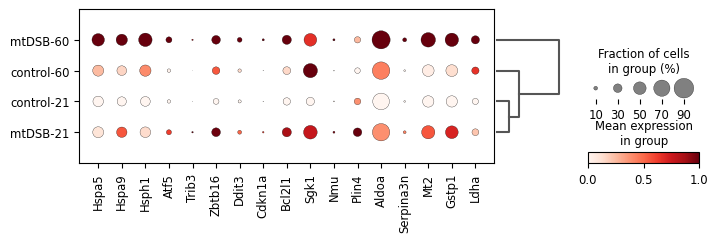

In [34]:
sc.pl.dotplot(
        sub,
        var_names=mtDSB_genes,
        groupby="condition-age",
        standard_scale="var",
        #dot_max=0.5,
        #dot_min=0.05,
        color_map="Reds",
        dendrogram=True,
        figsize=(8, 2)
    )

In [39]:
sub.obs["condition-age"]

cell_id
aaaaakjg-1    control-60
aaaefdnf-1    control-60
aaagdpma-1    control-60
aaalkdhd-1    control-60
aaallifg-1    control-60
                 ...    
oiebdiob-1    control-21
oieinkch-1    control-21
oifickba-1    control-21
oifjehlf-1    control-21
oigafpoe-1    control-21
Name: condition-age, Length: 184678, dtype: category
Categories (4, object): ['control-21', 'control-60', 'mtDSB-21', 'mtDSB-60']

In [41]:
expr

array([0.        , 0.08663423, 0.        , ..., 0.        , 0.        ,
       0.        ], dtype=float32)

In [46]:
import numpy as np
import pandas as pd

genes = mtDSB_genes  # your list

# subset to oligos + opcs

logfc = {}
for g in genes:
    if g not in subset.var_names:
        continue
    
    # get raw expression (use layer="counts" if you have raw counts stored)
    expr = sub[:, g].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray().ravel()
    else:
        expr = np.asarray(expr).ravel()
    
    cond = sub.obs["condition-age"].values
    mean_ctrl = expr[cond == "control-21"].mean()  # add small offset
    mean_ds   = expr[cond == "mtDSB-21"].mean()
    
    logfc[g] = np.log2(mean_ds / mean_ctrl)

df_logfc = pd.Series(logfc).sort_values(ascending=False)
print(df_logfc)

Trib3        3.988380
Cdkn1a       2.444013
Nmu          1.795862
Sgk1         1.494777
Serpina3n    1.196829
Atf5         0.998912
Zbtb16       0.922740
Plin4        0.630031
Bcl2l1       0.514454
Ddit3        0.502801
Gstp1        0.455521
Mt2          0.383855
Hspa9        0.329205
Ldha         0.168514
Hsph1        0.146988
Aldoa        0.119394
Hspa5        0.052544
dtype: float32


In [47]:
import numpy as np
import pandas as pd

genes = mtDSB_genes  # your list

# subset to oligos + opcs

logfc = {}
for g in genes:
    if g not in subset.var_names:
        continue
    
    # get raw expression (use layer="counts" if you have raw counts stored)
    expr = sub[:, g].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray().ravel()
    else:
        expr = np.asarray(expr).ravel()
    
    cond = sub.obs["condition-age"].values
    mean_ctrl = expr[cond == "control-60"].mean()  # add small offset
    mean_ds   = expr[cond == "mtDSB-60"].mean()
    
    logfc[g] = np.log2(mean_ds / mean_ctrl)

df_logfc = pd.Series(logfc).sort_values(ascending=False)
print(df_logfc)

Trib3        4.740580
Cdkn1a       3.373627
Nmu          2.352940
Serpina3n    1.966522
Atf5         1.344083
Ddit3        0.705190
Mt2          0.595970
Gstp1        0.510876
Bcl2l1       0.479974
Hspa9        0.444821
Hsph1        0.438484
Plin4        0.423822
Zbtb16       0.348405
Hspa5        0.331361
Ldha         0.193087
Aldoa        0.157830
Sgk1        -0.383631
dtype: float32


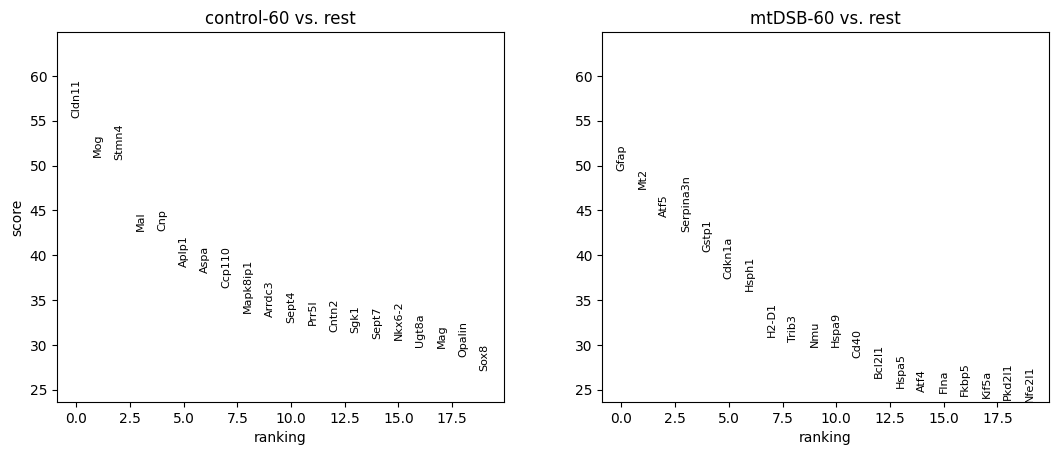

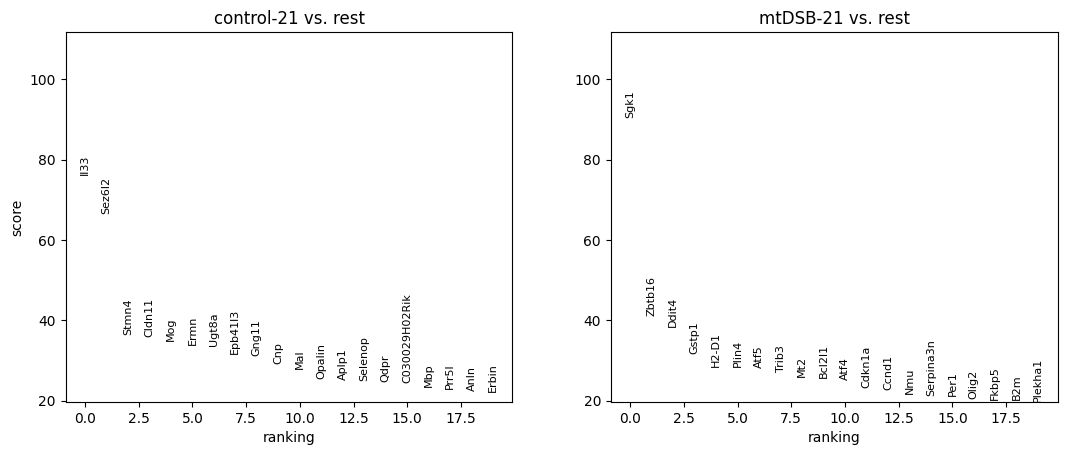

In [49]:
for i in sub.obs.age.unique():
    sub_s = sub[sub.obs.age == i]
    sc.tl.rank_genes_groups(sub_s, groupby="condition-age", method="t-test")
    sc.pl.rank_genes_groups(sub_s)

In [51]:
results = []
for age in subset.obs["age"].unique():
    for cond in subset.obs["condition"].unique():
        sub = subset[(subset.obs["age"] == age) & (subset.obs["condition"] == cond)]
        for g in genes:
            if g not in sub.var_names:
                continue
            expr = sub[:, g].X
            if hasattr(expr, "toarray"):
                expr = expr.toarray().ravel()
            else:
                expr = np.asarray(expr).ravel()
            results.append({
                "gene": g,
                "age": age,
                "condition": cond,
                "mean_expr": expr.mean()
            })

df_means = pd.DataFrame(results)

# pivot to get logFC for each age
df_pivot = df_means.pivot_table(index="gene", columns=["age","condition"], values="mean_expr")
df_pivot["logFC_mtDSB_vs_ctrl_21"] = np.log2((df_pivot['21',"mtDSB"]+1e-6)/(df_pivot['21',"control"]+1e-6))
df_pivot["logFC_mtDSB_vs_ctrl_60"] = np.log2((df_pivot['60',"mtDSB"]+1e-6)/(df_pivot['60',"control"]+1e-6))

In [52]:
df_pivot

age              21                  60           logFC_mtDSB_vs_ctrl_21  \
condition   control     mtDSB   control     mtDSB                          
gene                                                                       
Aldoa      0.249217  0.270719  0.273437  0.305049               0.119393   
Atf5       0.013768  0.027516  0.014139  0.035896               0.998860   
Bcl2l1     0.041357  0.059076  0.044462  0.062011               0.514444   
Cdkn1a     0.000991  0.005395  0.000793  0.008215               2.442826   
Ddit3      0.011619  0.016463  0.012973  0.021150               0.502764   
Gstp1      0.095631  0.131137  0.102279  0.145739               0.455517   
Hspa5      0.074782  0.077556  0.081939  0.103096               0.052543   
Hspa9      0.057134  0.071779  0.061384  0.083552               0.329200   
Hsph1      0.066887  0.074061  0.087031  0.117942               0.146986   
Ldha       0.030780  0.034594  0.042369  0.048436               0.168508   
Mt2        0.119829  0.156356  0.123017  0.185939               0.383853   
Nmu        0.014262  0.049521  0.010119  0.051695               1.795790   
Plin4      0.054711  0.084670  0.036297  0.048691               0.630021   
Serpina3n  0.004986  0.011431  0.005142  0.020097               1.196666   
Sgk1       0.059260  0.167006  0.199610  0.153003               1.494761   
Trib3      0.000385  0.006112  0.000203  0.005440               3.984874   
Zbtb16     0.028183  0.053426  0.042275  0.053822               0.922715   

age       logFC_mtDSB_vs_ctrl_60  
condition                         
gene                              
Aldoa                   0.157830  
Atf5                    1.344022  
Bcl2l1                  0.479965  
Cdkn1a                  3.371984  
Ddit3                   0.705147  
Gstp1                   0.510871  
Hspa5                   0.331357  
Hspa9                   0.444815  
Hsph1                   0.438479  
Ldha                    0.193083  
Mt2                     0.595966  
Nmu                     2.352825  
Plin4                   0.423812  
Serpina3n               1.966314  
Sgk1                   -0.383629  
Trib3                   4.733773  
Zbtb16                  0.348397